# Artificial Intelligence – Agents Laboratory Report
## Constructing a Goal-Based Agent using a Large Language Model
**Problem:** Warehouse Navigation  |  **Language:** Python 3  |  **LLM used:** Claude

---
## 0. What are we asked to do?

In this laboratory we build a **goal-based intelligent agent** for an autonomous warehouse vehicle. The vehicle starts at `S` on a grid map, must reach the goal `G`, and may not cross shelving (`#`). It can move Up, Down, Left or Right, one square at a time.

The focus is **not** Python programming. It is about:

1. **Specifying** the AI problem (environment, goal, actions, state).
2. **Designing** the agent (block diagram of a goal-based architecture).
3. **Using an LLM as a software-engineering assistant** with a well-structured prompt rather than a vague "write a program".
4. **Testing and validating** the generated code, and improving it by iterative prompting.
5. **Critically evaluating** what the LLM did well and where its limits are.

The assignment has three tasks:

| Task | Deliverable |
|---|---|
| 1 – Understanding the problem | Answers to five questions + "Think About It" |
| 2 – Designing the agent | Design description and block diagram |
| 3 – Prompt engineering | Prompt, working program, test results, answers to four reflection questions |

---
## Task 1 – Understanding the Problem

**1. What is the environment?**
A static, discrete 2-D grid warehouse (7 rows × 21 columns). Cells are free (`.`), obstacles (`#`), the start (`S`) or the goal (`G`). The environment is *fully observable* (the whole map is known), *deterministic* (a move always succeeds unless blocked), *static* (nothing moves while the agent plans), *discrete*, and *single-agent*.

**2. What is the goal of the agent?**
To reach the cell `G` from `S` via a collision-free path, ideally the shortest one (fewest moves).

**3. What actions are available?**
`Up`, `Down`, `Left`, `Right`. Each moves the vehicle by exactly one grid square and is legal only if the target cell is inside the grid and is not `#`. Each move has cost 1.

**4. What information must the agent maintain to choose its next action?**
- The **current state**: its position `(row, col)`.
- The **goal** state: position of `G`.
- A **model of the world**: the map, to know which moves are legal (the transition model).
- Search bookkeeping: a **frontier** (states still to be explored), an **explored/visited set** (to avoid loops) and **parent pointers** (to rebuild the path once the goal is found).

**5. Why is this a goal-based agent and not a simple reflex agent?**
A simple reflex agent maps the *current percept* directly to an action through condition–action rules (e.g. "if wall ahead, turn right"). It has no notion of a destination and no look-ahead, so it can loop forever or get stuck in dead ends (this map has several). A goal-based agent holds an explicit **goal**, uses a **model** of how actions change the state, and **searches** through sequences of hypothetical actions to find one that achieves the goal. The action it picks is justified by "does this move me toward G?" rather than by the current percept alone.

### Think About It – what if the warehouse were twice as large?
Breadth-first search (BFS) is still *correct and optimal* but its cost grows with the number of free cells. Doubling each dimension gives about 4× as many cells, so BFS explores about 4× as many states and needs about 4× as much memory for its frontier and visited set. Additional difficulties:

- **Memory** becomes the bottleneck before time does (BFS stores the whole frontier).
- **Uninformed search wastes effort** exploring in all directions; an *informed* search such as **A\*** with a Manhattan-distance heuristic expands far fewer nodes (demonstrated in Section 4.5).
- **Dynamic elements** (moving forklifts, people, changing shelf layouts) would need **re-planning**, which becomes expensive on large maps.
- **Partial observability** (a robot with limited sensors) would require a belief state/mapping (SLAM), not plain search.
- **Multiple vehicles** introduce coordination and deadlock problems.
- Real vehicles have **non-uniform costs** (turning, speed zones), so BFS would no longer be optimal and Dijkstra/A\* is needed.

---
## Task 2 – Designing the Agent

| Component | Design choice |
|---|---|
| **Environment** | 7×21 static warehouse grid with obstacles |
| **Current state** | Vehicle position `(row, col)` (start: `S`) |
| **Goal** | Position of `G`; goal test is `state == goal` |
| **Actions** | `Up`, `Down`, `Left`, `Right` (cost 1 each) |
| **Decision-making component** | A search procedure (BFS) that simulates action sequences using the world model and returns a plan |

The diagram below follows the goal-based agent architecture from the lecture: percepts tell the agent *what the world is like now*; the model tells it *what happens if I do action A*; the goal tells it *what I want*; the planner combines these to choose the actions.

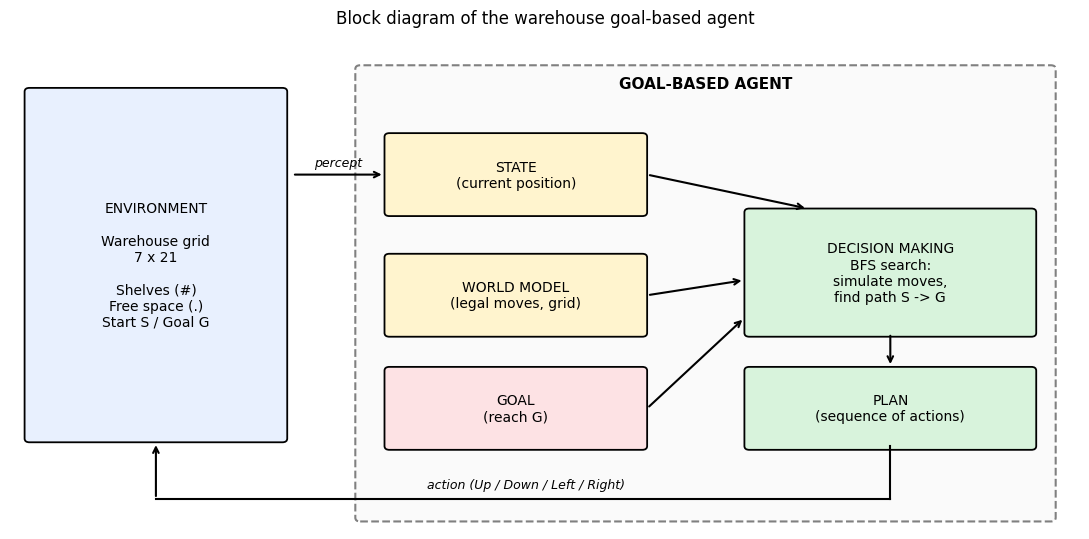

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.set_xlim(0, 11); ax.set_ylim(-0.6, 6); ax.axis("off")

def box(x, y, w, h, text, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                fc=color, ec="black", lw=1.3))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10)

def arrow(x1, y1, x2, y2, label=None, dy=0.12):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + dy, label, ha="center", fontsize=9, style="italic")

# Environment
box(0.2, 0.6, 2.6, 4.6, "ENVIRONMENT\n\nWarehouse grid\n7 x 21\n\nShelves (#)\nFree space (.)\nStart S / Goal G", "#e8f0fe")
# Agent outline
ax.add_patch(FancyBboxPatch((3.6, -0.45), 7.1, 5.95, boxstyle="round,pad=0.05",
                            fc="#fafafa", ec="gray", lw=1.5, ls="--"))
ax.text(7.15, 5.25, "GOAL-BASED AGENT", ha="center", fontsize=11, weight="bold")

box(3.9, 3.6, 2.6, 1.0, "STATE\n(current position)", "#fff4ce")
box(3.9, 2.0, 2.6, 1.0, "WORLD MODEL\n(legal moves, grid)", "#fff4ce")
box(3.9, 0.5, 2.6, 1.0, "GOAL\n(reach G)", "#fde2e4")
box(7.6, 2.0, 2.9, 1.6, "DECISION MAKING\nBFS search:\nsimulate moves,\nfind path S -> G", "#d8f3dc")
box(7.6, 0.5, 2.9, 1.0, "PLAN\n(sequence of actions)", "#d8f3dc")

arrow(2.9, 4.1, 3.85, 4.1, "percept")
arrow(6.55, 4.1, 8.2, 3.65)
arrow(6.55, 2.5, 7.55, 2.7)
arrow(6.55, 1.0, 7.55, 2.2)
arrow(9.05, 2.0, 9.05, 1.55)
ax.plot([9.05, 9.05], [0.5, -0.2], color="black", lw=1.5)
ax.plot([9.05, 1.5], [-0.2, -0.2], color="black", lw=1.5)
ax.annotate("", xy=(1.5, 0.55), xytext=(1.5, -0.2), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(5.3, -0.05, "action (Up / Down / Left / Right)", ha="center", fontsize=9, style="italic")

plt.title("Block diagram of the warehouse goal-based agent", fontsize=12)
plt.tight_layout(); plt.show()

**How the components interact:** the agent *perceives* its position (state) in the environment. The **decision-making** component takes the state, the **world model** (which moves are legal) and the **goal** (G), and searches for a sequence of actions that turns the current state into the goal state. The resulting **plan** is then executed as actions in the environment.

---
## Task 3 – Prompt Engineering

### 3.1 The prompt given to the LLM
Rather than "write a program", a structured specification was used:

> Write a well-documented Python program implementing a goal-based agent for the warehouse navigation problem shown above.
> The program should:
> - represent the warehouse as a two-dimensional grid;
> - determine a collision-free path from S to G;
> - avoid all obstacles;
> - print either the path found or a suitable message if no path exists;
> - explain the search algorithm that has been chosen and why it is appropriate.
>
> *(The warehouse map, the movement rules and the agent definition were included in the prompt.)*

### 3.2 Program generated (with documentation)
**Algorithm chosen: Breadth-First Search (BFS).**

In [2]:
"""
Goal-based agent for the Warehouse Navigation problem.

ALGORITHM: Breadth-First Search (BFS)
-------------------------------------
BFS explores states in order of increasing number of moves from the start.
Reasons it is appropriate here:
  * Every move costs the same (one grid square), so BFS is OPTIMAL: the first
    time it reaches G it has found a shortest path.
  * It is COMPLETE: if a path exists BFS will find it; if the frontier empties,
    no path exists and the agent can report that.
  * The state space is small (at most 7 x 21 = 147 cells), so its memory use
    is not a concern.
  * A visited set prevents revisiting cells, so it never loops.
"""
from collections import deque

WAREHOUSE_MAP = [
    "#####################",
    "#S....#............G#",
    "#.##....##########..#",
    "#....##.............#",
    "#.######.###.#.###..#",
    "#........#..........#",
    "#####################",
]

# Action name -> (row change, column change)
ACTIONS = {"Up": (-1, 0), "Down": (1, 0), "Left": (0, -1), "Right": (0, 1)}


class WarehouseEnvironment:
    """The environment: stores the grid and answers 'what happens if...' queries."""

    def __init__(self, rows):
        self.grid = [list(r) for r in rows]
        self.n_rows, self.n_cols = len(self.grid), len(self.grid[0])
        self.start = self._find("S")
        self.goal = self._find("G")

    def _find(self, symbol):
        for r, row in enumerate(self.grid):
            for c, ch in enumerate(row):
                if ch == symbol:
                    return (r, c)
        raise ValueError(f"Symbol {symbol!r} not found in the map")

    def is_free(self, pos):
        r, c = pos
        return (0 <= r < self.n_rows and 0 <= c < self.n_cols
                and self.grid[r][c] != "#")

    def successors(self, pos):
        """Transition model: yield (action, next_position) for every legal move."""
        for name, (dr, dc) in ACTIONS.items():
            nxt = (pos[0] + dr, pos[1] + dc)
            if self.is_free(nxt):
                yield name, nxt


class GoalBasedAgent:
    """Goal-based agent: plans a sequence of actions that reaches its goal."""

    def __init__(self, env):
        self.env = env
        self.nodes_expanded = 0

    def plan(self):
        """Return (list_of_positions, list_of_actions) or None if no path exists."""
        start, goal = self.env.start, self.env.goal
        frontier = deque([start])          # FIFO queue => breadth-first order
        parent = {start: None}             # also serves as the visited set
        self.nodes_expanded = 0

        while frontier:
            state = frontier.popleft()
            self.nodes_expanded += 1
            if state == goal:              # goal test
                return self._reconstruct(parent, state)
            for action, nxt in self.env.successors(state):
                if nxt not in parent:      # not visited before
                    parent[nxt] = (state, action)
                    frontier.append(nxt)
        return None                        # frontier exhausted: no path

    @staticmethod
    def _reconstruct(parent, state):
        positions, actions = [state], []
        while parent[state] is not None:
            state, action = parent[state]
            positions.append(state)
            actions.append(action)
        return positions[::-1], actions[::-1]


def render(env, path):
    """Return the map as text with the path drawn using '*'."""
    grid = [row[:] for row in env.grid]
    for (r, c) in path:
        if grid[r][c] == ".":
            grid[r][c] = "*"
    return "\n".join("".join(row) for row in grid)


def run(rows):
    env = WarehouseEnvironment(rows)
    agent = GoalBasedAgent(env)
    result = agent.plan()
    if result is None:
        print("No path exists from S to G.")
        return None
    path, actions = result
    print("Path found!")
    print(f"  Number of moves  : {len(actions)}")
    print(f"  Nodes expanded   : {agent.nodes_expanded}")
    print(f"  Actions          : {', '.join(actions)}")
    print(f"  Coordinates      : {path}\n")
    print(render(env, path))
    return path, actions


if __name__ == "__main__":
    run(WAREHOUSE_MAP)

Path found!
  Number of moves  : 20
  Nodes expanded   : 59
  Actions          : Right, Right, Right, Down, Right, Right, Right, Up, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right
  Coordinates      : [(1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 5), (2, 6), (2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19)]

#####################
#S***.#************G#
#.##****##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################


### 3.3 Running the program

In [3]:
result = run(WAREHOUSE_MAP)

Path found!
  Number of moves  : 20
  Nodes expanded   : 59
  Actions          : Right, Right, Right, Down, Right, Right, Right, Up, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right, Right
  Coordinates      : [(1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 5), (2, 6), (2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19)]

#####################
#S***.#************G#
#.##****##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################


### 3.4 Testing and validation
A program that "runs" is not necessarily correct. The tests below check that the agent's output is valid, that it is optimal and that it handles failure cases.

In [4]:
def validate_path(env, path, actions):
    '''Independent checker: replay the plan step by step in the environment.'''
    assert path[0] == env.start, "Path must begin at S"
    assert path[-1] == env.goal, "Path must end at G"
    pos = env.start
    for act in actions:
        dr, dc = ACTIONS[act]
        pos = (pos[0] + dr, pos[1] + dc)
        assert env.is_free(pos), f"Collision at {pos}"
    assert pos == env.goal
    return True

env = WarehouseEnvironment(WAREHOUSE_MAP)
path, actions = result

# Test 1: path is collision-free and connects S to G
print("Test 1 (valid, collision-free path):", validate_path(env, path, actions))

# Test 2: path is shortest -- cross-check with an independent distance computation
from collections import deque
def bfs_distance(env):
    dist = {env.start: 0}; q = deque([env.start])
    while q:
        s = q.popleft()
        for _, n in env.successors(s):
            if n not in dist:
                dist[n] = dist[s] + 1; q.append(n)
    return dist.get(env.goal)
print("Test 2 (optimal length):", len(actions) == bfs_distance(env), f"-> {len(actions)} moves")

# Test 3: no cell visited twice
print("Test 3 (no revisits):", len(set(path)) == len(path))

# Test 4: unreachable goal -> suitable message (goal walled in)
blocked = [
    "#####################",
    "#S....#............G#",
    "#.##....##########.##",
    "#....##...........###",
    "#.######.###.#.###..#",
    "#........#..........#",
    "#####################",
]
# Seal G completely:
blocked[1] = "#S....#...........#G#"
print("\nTest 4 (no path exists):")
run(blocked)

# Test 5: start == goal edge case can't occur on this map, so check a trivial neighbouring case
trivial = ["#####", "#SG.#", "#####"]
print("\nTest 5 (adjacent S and G):")
run(trivial)

Test 1 (valid, collision-free path): True
Test 2 (optimal length): True -> 20 moves
Test 3 (no revisits): True

Test 4 (no path exists):
No path exists from S to G.

Test 5 (adjacent S and G):
Path found!
  Number of moves  : 1
  Nodes expanded   : 2
  Actions          : Right
  Coordinates      : [(1, 1), (1, 2)]

#####
#SG.#
#####


([(1, 1), (1, 2)], ['Right'])

### 3.5 Visualising the solution and comparing search strategies
The text output is hard to read, so here is a graphical view. We also compare BFS with **DFS** and **A\*** to support the answers to "why BFS?" and to the "twice as large" question.

Algorithm Path length (moves)   Nodes expanded
BFS       20                    59
DFS       22                    34
A*        20                    23


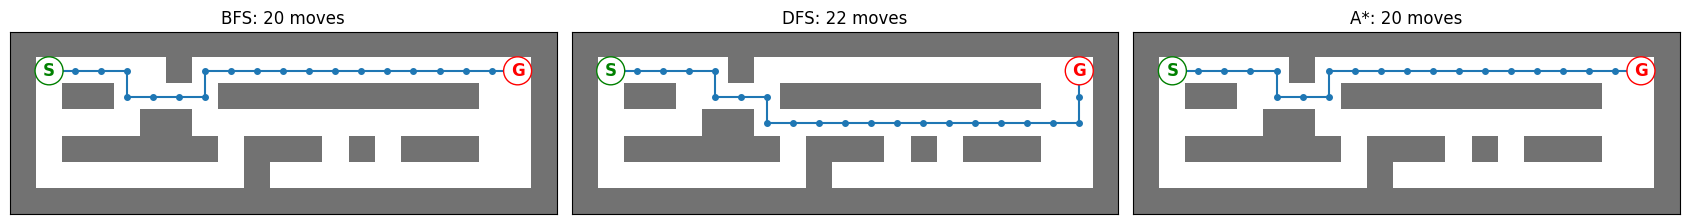

In [5]:
import heapq, numpy as np

def dfs_plan(env):
    stack = [env.start]; parent = {env.start: None}; expanded = 0
    while stack:
        s = stack.pop(); expanded += 1
        if s == env.goal:
            p = []
            while s is not None:
                p.append(s); s = parent[s][0] if parent[s] else None
            return p[::-1], expanded
        for a, n in env.successors(s):
            if n not in parent:
                parent[n] = (s, a); stack.append(n)
    return None, expanded

def astar_plan(env):
    h = lambda p: abs(p[0]-env.goal[0]) + abs(p[1]-env.goal[1])   # Manhattan distance
    openq = [(h(env.start), 0, env.start)]
    g = {env.start: 0}; parent = {env.start: None}; expanded = 0
    while openq:
        _, cost, s = heapq.heappop(openq)
        if cost > g[s]: continue
        expanded += 1
        if s == env.goal:
            p = []
            while s is not None:
                p.append(s); s = parent[s][0] if parent[s] else None
            return p[::-1], expanded
        for a, n in env.successors(s):
            if n not in g or cost + 1 < g[n]:
                g[n] = cost + 1; parent[n] = (s, a)
                heapq.heappush(openq, (cost + 1 + h(n), cost + 1, n))
    return None, expanded

agent = GoalBasedAgent(env)
bfs_path, _ = agent.plan()
bfs_exp = agent.nodes_expanded
dfs_path, dfs_exp = dfs_plan(env)
ast_path, ast_exp = astar_plan(env)

print(f"{'Algorithm':<10}{'Path length (moves)':<22}{'Nodes expanded'}")
print(f"{'BFS':<10}{len(bfs_path)-1:<22}{bfs_exp}")
print(f"{'DFS':<10}{len(dfs_path)-1:<22}{dfs_exp}")
print(f"{'A*':<10}{len(ast_path)-1:<22}{ast_exp}")

# Graphical rendering
grid = np.array([[1 if ch == "#" else 0 for ch in row] for row in WAREHOUSE_MAP])
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
for ax, (name, p) in zip(axes, [("BFS", bfs_path), ("DFS", dfs_path), ("A*", ast_path)]):
    ax.imshow(grid, cmap="Greys", vmin=0, vmax=1.6)
    ax.plot([c for r, c in p], [r for r, c in p], "-o", color="tab:blue", ms=4)
    ax.text(env.start[1], env.start[0], "S", color="green", ha="center", va="center", weight="bold", fontsize=12,
            bbox=dict(fc="white", ec="green", boxstyle="circle"))
    ax.text(env.goal[1], env.goal[0], "G", color="red", ha="center", va="center", weight="bold", fontsize=12,
            bbox=dict(fc="white", ec="red", boxstyle="circle"))
    ax.set_title(f"{name}: {len(p)-1} moves"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Observation.** BFS and A\* both return a shortest path. DFS returns *a* path but it is not guaranteed to be the shortest (it explores one branch as deep as possible), so it is unsuitable when efficiency of the route matters.

### 3.6 Scaling experiment ("Think About It")
We generate random warehouses of increasing size and compare how many nodes BFS and A\* expand. A fixed random seed keeps the result reproducible.

In [6]:
import random

def random_warehouse(n_rows, n_cols, density=0.25, seed=0):
    rnd = random.Random(seed)
    g = [["#"] * n_cols for _ in range(n_rows)]
    for r in range(1, n_rows - 1):
        for c in range(1, n_cols - 1):
            g[r][c] = "#" if rnd.random() < density else "."
    g[1][1] = "S"; g[n_rows-2][n_cols-2] = "G"
    return ["".join(row) for row in g]

print(f"{'Grid':<10}{'BFS expanded':<15}{'A* expanded':<15}{'Moves (BFS/A*)'}")
for scale in (1, 2, 4, 8):
    rows, cols = 7 * scale, 21 * scale
    for seed in range(50):                     # find a solvable random map
        m = random_warehouse(rows, cols, 0.2, seed)
        e = WarehouseEnvironment(m)
        a = GoalBasedAgent(e); res = a.plan()
        if res: break
    ap, ae = astar_plan(e)
    print(f"{rows}x{cols:<6}{a.nodes_expanded:<15}{ae:<15}{len(res[1])}/{len(ap)-1}")

Grid      BFS expanded   A* expanded    Moves (BFS/A*)
7x21    86             86             22/22
14x42    387            332            50/50
28x84    1702           951            106/106
56x168   7193           4168           218/218


The number of nodes BFS must expand grows roughly with the area of the map, whereas A\*'s growth is usually smaller because the heuristic steers it toward the goal. This supports the answer to "Think About It": BFS remains correct at larger scale but becomes progressively less efficient.

### 3.7 Answers to the Task 3 questions

**1. Did the LLM generate a working program on the first attempt?**
Yes. The program ran without errors and produced a valid, shortest path (Section 3.3) and passed all tests in Section 3.4. The reason is that the prompt was specific: it gave the complete map, the legal moves, the required output and a request for an explanation. *(If your own LLM session produced errors, record them here: paste the error message, describe how you asked the LLM to fix it, and note how many iterations were needed.)*

**2. If not, how can you improve your prompt?**
Even though the first attempt worked, the prompt can be improved to make the result more robust and more useful:
- State the **exact output format** ("print the path as a list of coordinates and draw it on the map with `*`").
- Specify the **cost model** and **optimality** ("the path must be a shortest path").
- Require **edge-case handling** ("if no path exists, print a message") and **tests**.
- Give **constraints** on code structure ("separate Environment and Agent classes; use only the standard library").
- Provide the map **as a string in a code block**, because a map pasted from a PDF can lose line breaks or alignment and cause the LLM to misread the grid.
- If the output is wrong, **iterate**: paste the error or the incorrect output into the next prompt, instead of starting over.

**3. What search algorithm did the LLM choose?**
**Breadth-First Search (BFS)**, using a FIFO queue, a visited set (the `parent` dictionary) and parent pointers to reconstruct the path.

**4. Why do you think the LLM selected this algorithm?**
- The task is an *unweighted shortest-path* problem on a grid, and BFS is the textbook algorithm for it: it is **complete** and **optimal** when all step costs are equal.
- The grid is **small**, so BFS's memory cost is irrelevant, and it is the simplest correct choice that is easy to explain, which the prompt asked for.
- BFS needs **no heuristic**, so there is no risk of an inadmissible heuristic harming optimality.
- It is also the most common solution to "find a path through a maze" in the LLM's training data, so it is the highest-probability answer. That is a *statistical* reason rather than a reasoned engineering choice, which matters when the problem is unusual.
- A\* would be the better choice for a much larger warehouse (Section 3.6), but it adds complexity that this problem does not need.

---
## 4. Critical Evaluation of LLM-Assisted Software Engineering (Learning Objective 5)

**Strengths**
- Produced a correct, well-structured and documented program quickly.
- Good at explaining the algorithm and justifying the choice.
- Makes it easy to ask for variations (DFS, A\*, visualisation) and to iterate.
- Lets the student concentrate on *problem specification and agent design*, which is the point of the lab.

**Limitations and risks**
- The LLM can generate code that **looks plausible but is wrong** (e.g. off-by-one in bounds checking, a path that cuts through walls). Only **testing** reveals this, which is why an independent `validate_path` checker was written rather than trusting the output.
- Output quality depends heavily on **prompt quality**; ambiguity in the prompt (or a garbled map) leads to ambiguous code.
- The LLM picks the **most common** solution, not necessarily the best one for the specific constraints (here BFS is fine, but for larger maps it would not be).
- It does not *understand* the warehouse; it cannot know about requirements that were not stated (turning costs, moving obstacles).
- **Accountability** remains with the engineer: the code must be read, understood, tested and, where needed, corrected before use.

## 5. Conclusion
A goal-based agent for the warehouse problem was specified, designed and implemented with LLM assistance. The agent uses **BFS** to plan a shortest, collision-free path from `S` to `G`, correctly reports when no path exists, and was validated with independent tests. Comparison with DFS and A\* and the scaling experiment show why BFS is sufficient here but would need to be replaced by an informed search as the warehouse grows. The main lesson is that the LLM is a powerful assistant, but the quality of the final system depends on a precise problem specification and on rigorous testing by the human engineer.